# AFRO-PRODUCTIONS ANALYSIS

Authors: 
- Angela Masaki
- Joy Nyuguto
- David Theuri
- Joel Muoki
- Felista Mwangi

Date:March 2026

## Overview


This notebook presents an  exploratory data analysis (EDA) to direct the opening of a new movie film studio.We determine what distinguishes high-performing movies from low-performing ones using box office, budget, and genre data from various sources.


## Business Understanding

### Key Stakeholder
The Head of the New Movie Studio (Afro Productions)

### Business Problem

Despite having no  prior experience producing movies,our company,Afro Productions, wants to get into the original video content business. Without historical insight, every decision,including genre, budget, release date, target markets, and current performing studios,is an expensive bet. Before it ever gets off the ground, an underperforming  first film might cost millions of dollars and ruin the business.

### Key Business Questions
Q1.What film genres give the best return on investment?

Q2.What production budget range maximizes profiatability?

Q3.Which release month generates the highest box office gross?

Q4.Should our studio prioritize domestic or international markets?

Q5.Which studios should we model ourselves after?

---



## Data Understanding
We  are using  **three CSV datasets**  extracted from different industry sources.
Each one contributes something different to our analysis.



---



### Importing libraries

In [43]:
# Import important libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Loading the 'csv' movie data sets

In [44]:
# loading the data 
bom = pd.read_csv('../zippedData/bom.movie_gross.csv.gz')
tmdb = pd.read_csv('../zippedData/tmdb.movies.csv.gz')
tn = pd.read_csv('../zippedData/tn.movie_budgets.csv.gz')


### Data Previews

In [45]:
# Data sets shape(row,columns)
print(f'tn shape:{tn.shape}')
print(f'tmdb shape:{tmdb.shape}')
print(f'bom shape:{bom.shape}')

print("-" * 30)
#
print(f'tn columns:{list(tn.columns)}')
print(f'tmdb columns:{list(tmdb.columns)}')
print(f'bom columns:{list(bom.columns)}')

tn shape:(5782, 6)
tmdb shape:(26517, 10)
bom shape:(3387, 5)
------------------------------
tn columns:['id', 'release_date', 'movie', 'production_budget', 'domestic_gross', 'worldwide_gross']
tmdb columns:['Unnamed: 0', 'genre_ids', 'id', 'original_language', 'original_title', 'popularity', 'release_date', 'title', 'vote_average', 'vote_count']
bom columns:['title', 'studio', 'domestic_gross', 'foreign_gross', 'year']


| Source | File | Key Columns | Size |
|--------|------|-------------|------|
| The Numbers | `tn_movie_budgets.csv` | id, release_date, movie, production_budget, domestic_gross, worldwide_gross| 5,782 rows ,6 columns |
| TheMovieDB | `tmdb_movies.csv` | Unnamed: 0, genre_ids, id, original_language, original_title, popularity, release_date, title, vote_average, vote_count| 26,517 rows,10 columns|
| Box Office Mojo | `bom_movie_gross.csv` | title, studio, domestic_gross, foreign_gross, year | 3,387 rows,5 columns|


**Why these datasets?**
- tn_movie_budgets.csv(tn) provides budget and revenue data   -essential for computing ROI.
- tmdb_movies.csv(tmdb) provides genre and popularity metadata -useful for understanding movie genre performance.
- bom_movie_gross.csv(bom)provides domestic vs. foreign splits  - useful for understanding market reach.


## Data Preparation

Before analysis, all three datasets required cleaning to ensure the data was accurate, consistent and ready for use.


### Displaying sections of the movie data sets

In [46]:
# Data preview
print("The Numbers (tn):")
display(tn.head())

print("The Movie DB (tmdb):")
display(tmdb.head())

print("Box Office Mojo (bom):")
display(bom.head()) 




The Numbers (tn):


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


The Movie DB (tmdb):


,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


Box Office Mojo (bom):


,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


### Cleaning The Numbers :`tn_movie_budgets.csv`(tn)




- Renamed `id` to `rank` since the column represents budget ranking, not a unique identifier
- Stripped `$` signs and commas from the three money columns (`production_budget`, `domestic_gross`, `worldwide_gross`) and converted them from strings to floats
- Replaced `$0` entries with `NaN` since a film with zero budget or zero gross is likely a data entry error
- Dropped rows missing any of the three financial columns since these are essential for our analysis
- Parsed `release_date` from string to datetime and extracted `year` and `month` as separate columns
- **5,234 rows remaining after cleaning**

In [47]:
#  Rename 'id' to  'rank' (not a true unique ID)- instead it represents rank according to production budget rank 
tn = tn.rename(columns={'id': 'rank'})

#Removing commas and $ signs from money columns then converting to numbers
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
       tn[col] = tn[col].str.replace('$', '', regex=False)
       tn[col] = tn[col].str.replace(',', '', regex=False)
       tn[col] = tn[col].astype(float)   


#Repacing 0 values in columns with Nan
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
    tn[col] = tn[col].replace(0, np.nan)

# Dropping rows with missing financial data values 
tn = tn.dropna(subset=['production_budget', 'domestic_gross', 'worldwide_gross'])

#Parsing release date
tn['release_date'] = pd.to_datetime(tn['release_date'])

# Extracting release year and months into their own columns
tn['year'] = tn['release_date'].dt.year
tn['month'] = tn['release_date'].dt.month

print("tn after cleaning")
print(tn.dtypes)
print()
print(tn.isnull().sum())
print()
print(tn.head())




tn after cleaning
rank                          int64
release_date         datetime64[ns]
movie                        object
production_budget           float64
domestic_gross              float64
worldwide_gross             float64
year                          int32
month                         int32
dtype: object

rank                 0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
year                 0
month                0
dtype: int64

   rank release_date                                        movie  \
0     1   2009-12-18                                       Avatar   
1     2   2011-05-20  Pirates of the Caribbean: On Stranger Tides   
2     3   2019-06-07                                 Dark Phoenix   
3     4   2015-05-01                      Avengers: Age of Ultron   
4     5   2017-12-15            Star Wars Ep. VIII: The Last Jedi   

   production_budget  domestic_gross  worldwide_gross  year  month

### Cleaning Movie DB :`tmdb_movies.csv`(tmdb)



- Dropped the unnamed index column which added no value
- Parsed `release_date` from string to datetime and extracted `year` and `month`
- Removed rows with empty genre lists (`[]`) since genre is central to our analysis
- Converted `genre_ids` from a string representation into actual Python lists
- Removed films with fewer than 10 votes since ratings based on very few reviews are unreliable
- Decoded genre IDs into readable names (e.g. `28` to `Action`) using the official TMDB genre mapping and stored the first listed genre as `primary_genre`
- **10,348 rows remaining after cleaning**

In [48]:

# Dropping the unnamed index column 
tmdb = tmdb.drop(columns=['Unnamed: 0'])

# Parsing release_date from string to datetime
tmdb['release_date'] = pd.to_datetime(tmdb['release_date'])

# Extracting year and month
tmdb['year'] = tmdb['release_date'].dt.year
tmdb['month'] = tmdb['release_date'].dt.month

# Dropping  rows where genre_ids is empty 
tmdb = tmdb[tmdb['genre_ids'] != '[]']

# Convert genre_ids from a string like "[12, 14]" to an actual Python list
import ast
tmdb['genre_ids'] = tmdb['genre_ids'].apply(ast.literal_eval)

# Drop films with fewer than 10 votes since they are unreliable
tmdb = tmdb[tmdb['vote_count'] >= 10]

# Genre ID to name dictionary (official TMDB genre IDs)
GENRE_MAP = {
    28: 'Action',    12: 'Adventure',  16: 'Animation',   35: 'Comedy',
    80: 'Crime',     99: 'Documentary',18: 'Drama',     10751: 'Family',
    14: 'Fantasy',   36: 'History',    27: 'Horror',    10402: 'Music',
  9648: 'Mystery', 10749: 'Romance',  878: 'Sci-Fi',   10770: 'TV Movie',
    53: 'Thriller', 10752: 'War',      37: 'Western'
}

# Getting  the first genre from each list and mappin it to a name
tmdb['primary_genre'] = tmdb['genre_ids'].apply(lambda x: GENRE_MAP.get(x[0], 'Unknown'))

# Dropping rows where genre couldn't be decoded
tmdb = tmdb[tmdb['primary_genre'] != 'Unknown']


print("tmdb after cleaning")
print(f"Rows remaining: {len(tmdb)}")
print(tmdb.dtypes)
print()
print(tmdb.isnull().sum())
print()
print(tmdb.head())

tmdb after cleaning
Rows remaining: 10348
genre_ids                    object
id                            int64
original_language            object
original_title               object
popularity                  float64
release_date         datetime64[ns]
title                        object
vote_average                float64
vote_count                    int64
year                          int32
month                         int32
primary_genre                object
dtype: object

genre_ids            0
id                   0
original_language    0
original_title       0
popularity           0
release_date         0
title                0
vote_average         0
vote_count           0
year                 0
month                0
primary_genre        0
dtype: int64

             genre_ids     id original_language  \
0      [12, 14, 10751]  12444                en   
1  [14, 12, 16, 10751]  10191                en   
2        [12, 28, 878]  10138                en   
3      [16, 35, 1

### Cleaning Box Office Mojo `bom_movie_gross.csv` (bom)

- Dropped 5 rows with missing studio information
- Converted `foreign_gross` from string to float using `pd.to_numeric`
- Created a `total_gross` column by summing domestic and foreign gross
- Dropped rows where **both** domestic and foreign gross were missing  and rows with at least one value were kept
- **3,382 rows remaining after cleaning**

In [49]:

# Drop rows with missing studio values
bom = bom.dropna(subset=['studio'])

# Convert foreign_gross from string to float
bom['foreign_gross'] = pd.to_numeric(bom['foreign_gross'], errors='coerce')

# Computing total gross 
bom['total_gross'] = bom['domestic_gross'].fillna(0) + bom['foreign_gross'].fillna(0)

# Dropping  rows with missing  BOTH domestic and foreign gross values
bom = bom.dropna(subset=['domestic_gross', 'foreign_gross'], how='all')

print("bom after cleaning")
print(f"Rows remaining: {len(bom)}")
print(bom.dtypes)
print()
print(bom.isnull().sum())
print()
print()
print(bom.head())

bom after cleaning
Rows remaining: 3382
title              object
studio             object
domestic_gross    float64
foreign_gross     float64
year                int64
total_gross       float64
dtype: object

title                0
studio               0
domestic_gross      26
foreign_gross     1354
year                 0
total_gross          0
dtype: int64


                                         title studio  domestic_gross  \
0                                  Toy Story 3     BV     415000000.0   
1                   Alice in Wonderland (2010)     BV     334200000.0   
2  Harry Potter and the Deathly Hallows Part 1     WB     296000000.0   
3                                    Inception     WB     292600000.0   
4                          Shrek Forever After   P/DW     238700000.0   

   foreign_gross  year   total_gross  
0    652000000.0  2010  1.067000e+09  
1    691300000.0  2010  1.025500e+09  
2    664300000.0  2010  9.603000e+08  
3    535700000.0  2010  8.283000e+08  
4 

## Data Analysis and Visulization

#### Q1.What film genres give the best return on investment(ROI)?

#### Merging financial data (from tn) and genre information (from tmdb) on Movie Title

In [50]:
# Merging tn and tmdb on movie title
# Converting all titles to lowercase and removing extra spaces for proper matching
tn['title_key']  = tn['movie'].str.lower().str.strip()
tmdb['title_key'] = tmdb['title'].str.lower().str.strip()

#  Avoiding duplicates after merging(dropping possible duplicates) 
tmdb_dup = tmdb.drop_duplicates(subset='title_key')[['title_key', 'primary_genre']]

# Using inner join to merge 
tn_genre = tn.merge(tmdb_dup, on='title_key', how='inner')

print(f"Films matched to a genre: {len(tn_genre)}")

#Computing profit and ROI 
tn_genre['profit'] = tn_genre['worldwide_gross'] - tn_genre['production_budget']
tn_genre['roi']    = (tn_genre['profit'] / tn_genre['production_budget']) * 100

#  Median ROI per genre 
genre_roi = (tn_genre.groupby('primary_genre')['roi']
             .median()
             .sort_values(ascending=False).head(10)
             .reset_index())
genre_roi.columns = ['genre', 'median_roi']
print(genre_roi)

Films matched to a genre: 1642
       genre  median_roi
0   TV Movie  344.766110
1     Horror  307.492300
2    Mystery  217.238065
3  Animation  209.097806
4     Family  199.204940
5    History  156.895104
6    Romance  147.245329
7     Action  146.361160
8     Sci-Fi  138.493409
9  Adventure  134.790394


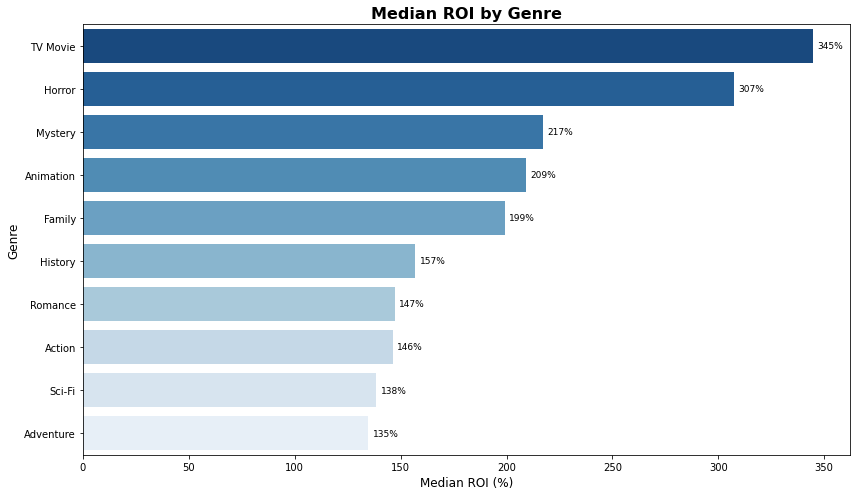

In [51]:
#Plotting bar plot
plt.figure(figsize=(12, 7))

ax = sns.barplot(data=genre_roi, x='median_roi', y='genre', palette='Blues_r')

#Adding values to each bar
for i, value in enumerate(genre_roi['median_roi']):
    plt.text(value + 2, i, f'{value:.0f}%', va='center', fontsize=9)

plt.title('Median ROI by Genre', fontsize=16, fontweight='bold')
plt.xlabel('Median ROI (%)', fontsize=12)
plt.ylabel('Genre', fontsize=12)

plt.tight_layout()
plt.savefig('../images/q1_genre_roi.png')
plt.show()

#### Q2 Finding

 - **Horror(307 %)**,**Mystery(217%)** and Animation deliver the highest median ROI among all genres meaning these films consistently earn back more than double their production budget as they are produced on relatively small budgets, so even average box office performance translates into strong returns
 - Although TV Movie ranks first at 345% ROI, we have excluded it from this recommendation because it refers to television productions rather than theatrical film releases, which is the focus of this analysis

#### Q2.What production budget range maximizes profitability?

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


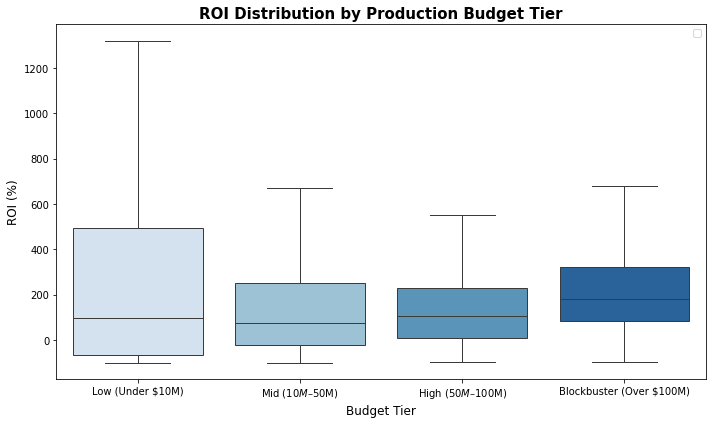

In [52]:
# Computing profit and ROI on tn 

# Adding a profit column: worldwide gross minus production budget
tn['profit'] = tn['worldwide_gross'] - tn['production_budget']

# Adding an roi column: profit divided by budget multiplied by 100
tn['roi']    = (tn['profit'] / tn['production_budget']) * 100

# Grouping films into budget tiers so to compare performance across different spending levels
# Blockbuster-a film with a very large production budget
budget_bins   = [0, 10e6, 50e6, 100e6, float('inf')]
budget_labels = ['Low (Under $10M)', 'Mid ($10M–$50M)', 'High ($50M–$100M)', 'Blockbuster (Over $100M)']

# pd.cut divides the data into buckets based on the ranges we defined in budget_bins
# each film gets labelled with the tier it falls into
tn['budget_tier'] = pd.cut(tn['production_budget'], bins=budget_bins, labels=budget_labels)

# Plot — box plot showing ROI spread within each budget tier
plt.figure(figsize=(10, 6))

sns.boxplot(data=tn, x='budget_tier',y='roi',palette='Blues',order=budget_labels,showfliers=False)

plt.title('ROI Distribution by Production Budget Tier', fontsize=15, fontweight='bold')
plt.xlabel('Budget Tier', fontsize=12)
plt.ylabel('ROI (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../images/q2_distribution_production_tier.png')
plt.show()

#### Q2 Finding

- **Low budget films (Under $10M)** have the widest box — meaning their ROI is very unpredictable,
  some films do extremely well but many lose money
- **Blockbuster films (Over $100M)** have a higher and more consistent ROI — 
  the median line sits around 200% and the box is tighter
- As budget increases the boxes get **smaller and higher** — 
  meaning bigger budget films are both more profitable and more predictable


#### Q3.Which release month generates the highest box office gross?

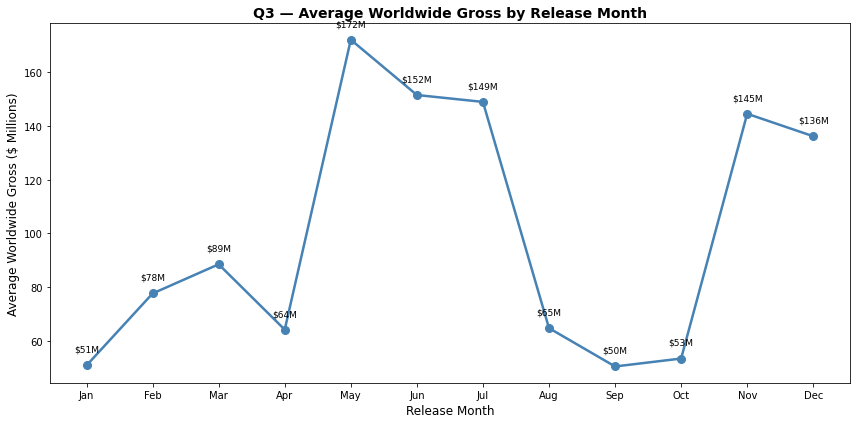

In [53]:
# Calculating average worldwide gross for each month
monthly_gross = tn.groupby('month')['worldwide_gross'].mean().reset_index()

# Mapping month numbers to month names 
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly_gross['month_name'] = monthly_gross['month'].map(month_names)

#line plot showing how average gross changes across the year
plt.figure(figsize=(12, 6))

plt.plot(monthly_gross['month_name'],monthly_gross['worldwide_gross'] / 1e6, marker='o',linewidth=2.5,color='steelblue',markersize=8)

# Adding labels for values
for i, row in monthly_gross.iterrows():
    plt.text(i,row['worldwide_gross'] / 1e6 + 5,f"${row['worldwide_gross']/1e6:.0f}M", ha='center',fontsize=9
    )

plt.title('Q3 — Average Worldwide Gross by Release Month', fontsize=14, fontweight='bold')
plt.xlabel('Release Month', fontsize=12)
plt.ylabel('Average Worldwide Gross ($ Millions)', fontsize=12)

plt.tight_layout()
plt.savefig('../images/q3_gross_release_month.png')
plt.show()

### Q3 Finding
- Films released in May ($172M), June ($152M), and July ($149M) earn significantly more on average than films released in any other month, with May standing out as the single best month to release a film. 
- November ($145M) and December ($136M) also perform well, while January ($51M), September ($50M), and October ($53M) are consistently the weakest months across the dataset.

#### Q4.Should our studio prioritize domestic or international markets?



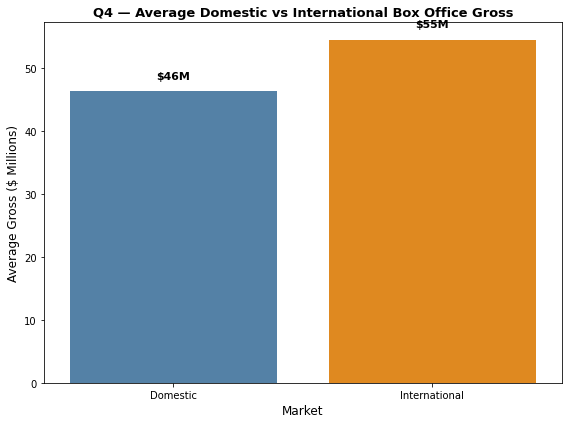

In [54]:
# Calculating international gross
tn['international_gross'] = tn['worldwide_gross'] - tn['domestic_gross']

# Calculate the average gross for each market
avg_domestic       = tn['domestic_gross'].mean() / 1e6
avg_international  = tn['international_gross'].mean() / 1e6

# Using asmall dataframe for easy plotting
market_df = pd.DataFrame({
    'Market'      : ['Domestic', 'International'],
    'Average Gross': [avg_domestic, avg_international]
})

# bar plot
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=market_df,x='Market',y='Average Gross',palette=['steelblue', 'darkorange']
)

# Adding  labels to bar values
for i, value in enumerate(market_df['Average Gross']):
    plt.text(i, value + 2, f'${value:.0f}M', ha='center', fontsize=11, fontweight='bold')

plt.title('Q4 — Average Domestic vs International Box Office Gross', fontsize=13, fontweight='bold')
plt.xlabel('Market', fontsize=12)
plt.ylabel('Average Gross ($ Millions)', fontsize=12)

plt.tight_layout()
plt.savefig('../images/q4_Domestic_International_gross.png')
plt.show()

### Q4 Finding
- On average, films earn more internationally ($55M) than domestically ($46M), meaning the global audience is actually a bigger revenue source than the home market alone 
- International audiences contribute about 20% more to a film's earnings than domestic ones.

#### Q5.Which studios should we model ourselves after?

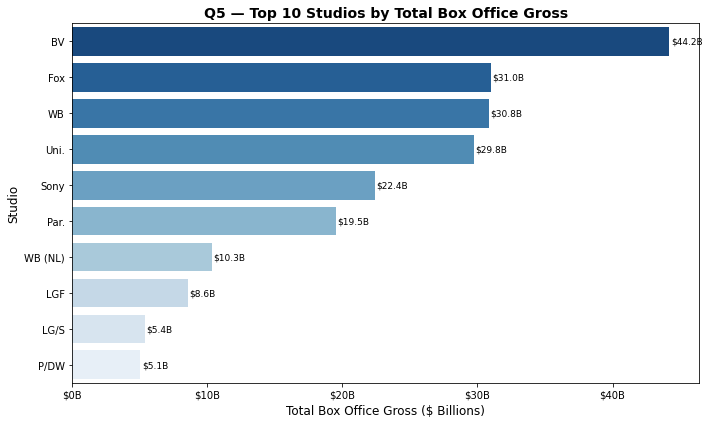

In [55]:
#Grouping by studio and sum total gross, then picking top 10
top_studios = (
    bom.groupby('studio')['total_gross']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Bar Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=top_studios,x='total_gross',y='studio',palette='Blues_r'
)

# Adding labels to bar values
labels = [f'${value/1e9:.1f}B' for value in top_studios['total_gross']]
for i, value in enumerate(top_studios['total_gross']):
    plt.text(value + 0.1e9, i, f'${value/1e9:.1f}B', va='center', fontsize=9)

plt.title('Q5 — Top 10 Studios by Total Box Office Gross', fontsize=14, fontweight='bold')
plt.xlabel('Total Box Office Gross ($ Billions)', fontsize=12)
plt.ylabel('Studio', fontsize=12)

# Formating x-axis to show billions instead of raw numbers
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e9:.0f}B'))

plt.tight_layout()
plt.savefig('../images/q5_Studios_total_gross.png')
plt.show()

### Q5 Finding
- Buena Vista (Disney) leads all studios at $44.2B, nearly $13B ahead of second-placed Fox ($31.0B), showing it is highly dominant .
- The top four studios including  Buena Vista, Fox, Warner Bros, and Universal , all crossed $29B, while the remaining six studios earned significantly less, suggesting there is a clear gap between industry leaders and the rest of the studios.

### Recommendations
##### Q1 Recommendation 
- Horror and Mystery are the safest starting genres for a studio with no track record. They require smaller budgets, carry lower financial risk, and have historically delivered strong returns

##### Q2 Recommendation 
- The studio should target **Blockbuster budgets (Over $100M)** — they offer the strongest and most consistent returns
- Note:Blockbuster means a film with a very large production budget

##### Q3 Recommendation 
- Release the first film in May or June, as these months have historically attracted the largest audiences and generated the highest box office returns. Additionally November is a reliable backup. 

##### Q4 Recommendation
- Prioritize securing international distribution from the start, as the data shows the global market consistently delivers higher returns than the domestic market alone.

##### Q5 Recommendation
- Our company should model itself after Buena Vista and Universal, studying the genres they invest in, their budget ranges, and how they approach international distribution to build a winning strategy from the ground up.